# NorESM Binned CCN–CDNC Susceptibility

**Scientific question:** How does CCN–CDNC susceptibility vary with CCN cutoff radius when the relationship is estimated by **binning CCN into log-spaced bins** and regressing bin-mean CDNC on bin-mean CCN? Binning suppresses sampling noise and exposes the mean response; the regression standard error gives a 95% CI.

CDNC is masked to in-cloud points (`FREQL > 0.8`). Susceptibility is the slope in log–log space, so the bin averaging is done on **log-transformed** values (geometric mean), not linear means — see Section 3.

**Input:** per-station NorESM/OsloAero file.  
**Output:** `reg_ds` (slope, r_value, std_err per station/radius), optionally saved.

---
*Sections: 1 Setup · 2 Load & cloud-mask · 3 Bin & regress · 4 Plots · 5 Save.*

## 1 · Setup and configuration

In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Configuration
NOR_PATH = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
RADII    = np.logspace(0, 2.7, 31)     # CCN cutoff radii [nm], ~1 to 500 nm
VAR_LIST = ['FREQL', 'Z3']             # cloud fraction + geopotential height
D_GRID   = xr.DataArray(np.logspace(-0.5, 6, num=200), dims=['D'],
                        coords={'D': np.logspace(-0.5, 6, num=200)})
CCN_BIN_NUMBER = 50      # Number of bins for CCN/CDNC regression
ds = xr.open_dataset(f'{NOR_PATH}', engine='netcdf4')  # to store results for all stations
# Optional: where to save reg_ds at the end (set to None to skip saving)
SAVE_PATH = '/share/pech2273/NorESM_Susceptibility_All_level.nc'

In [3]:
ds.NCONC10.mean('time').isel(lev = -1).values

array([0.13403443, 0.19408862, 0.39994538, 1.2898357 , 0.16162822,
       0.04161255, 0.7187899 , 0.11864546, 0.6286249 , 0.17479819,
       0.5541229 , 0.12069976, 0.01885465, 1.4475702 , 0.52650976],
      dtype=float32)

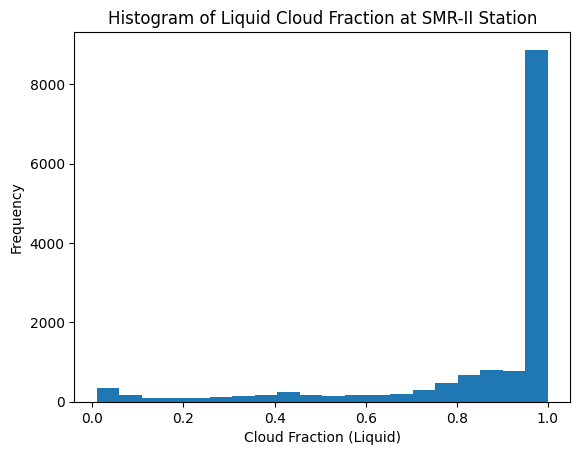

In [4]:
plt.hist(ds.FREQL.sel(station = 'SMR-II').where(ds.FREQL.sel(station = 'SMR-II') > 0).values.flatten(), bins=20)
plt.xlabel('Cloud Fraction (Liquid)')
plt.ylabel('Frequency')
plt.title('Histogram of Liquid Cloud Fraction at SMR-II Station')
plt.show()

## 2 · Load, build CCN, and cloud-mask CDNC

`CCN_CDNC_Dataset` aligns and packages CCN and CDNC. The build loop integrates the aerosol size distribution into CCN per cutoff radius (`NorERF`), masks CDNC to in-cloud points (`FREQL > 0.8`), and stacks all stations. `.compute()` materializes the result for the binning loop.

In [5]:
def CCN_CDNC_Dataset(CCN_ds, CDNC_da):
    """Align CCN(radius, lev, time) and CDNC(lev, time) and package together."""
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)
    return xr.Dataset(
        data_vars={'CCN': CCN_aligned, 'CDNC': CDNC_aligned},
        coords={'radius': CCN_aligned.radius,
                'lev': CCN_aligned.lev,
                'time': CCN_aligned.time},
    )

In [6]:
all_stationsCCN = []
all_stationsHeight = []

for station in ds['station'].values:
    Nor_ds = Function.NorESMExtract_Dask(NOR_PATH, station, VAR_LIST, D_GRID, PNSD=False)
    CCN_ds = Function.NorERF(Nor_ds, RADII)
    height = Nor_ds['Z3'].mean('time')

    # Mask CDNC to in-cloud points (cloud fraction > 0.8)
    Levels_CCN_ds = CCN_CDNC_Dataset(CCN_ds, Nor_ds['CDNC'].where(Nor_ds['FREQL'] > 0.8))

    all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))
    all_stationsHeight.append(height.assign_coords(station=station))

CCN_all    = xr.concat(all_stationsCCN, dim='station').compute()
Height_all = xr.concat(all_stationsHeight, dim='station')

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [7]:
print(type(CCN_all))
print(CCN_all)        # confirm data_vars include CDNC and CCN

<class 'xarray.core.dataset.Dataset'>
<xarray.Dataset> Size: 1GB
Dimensions:  (station: 15, radius: 31, time: 8761, lev: 32)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
  * station  (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * radius   (radius) float64 248B 1.0 1.23 1.514 1.862 ... 331.1 407.4 501.2
Data variables:
    CCN      (station, radius, time, lev) float64 1GB 0.1423 0.2716 ... 0.8596
    CDNC     (station, time, lev) float32 17MB nan nan nan nan ... nan nan nan


In [8]:
import os
path = '/share/pech2273/NorESM_CCN_CDNC.nc'
if os.path.exists(path): os.remove(path)
CCN_all.to_netcdf(path)
print(os.path.getsize(path), "bytes")   # should be >> 0

1059815555 bytes


## 3 · Bin by CCN and regress (log-space averaging)

For each (station, radius): bin both CCN and CDNC by CCN value, then average the **log10-transformed** values within each bin and OLS-fit. 

**Why log-first:** susceptibility is a log–log slope, so the correct per-bin summary is the geometric mean (mean of logs), not the arithmetic mean of the raw values. Averaging in linear space and then logging biases the bin points upward (Jensen's inequality on skewed, ~lognormal CCN/CDNC) and distorts the slope. Binning is still keyed on the original linear CCN values and there are equal number of data points in each bin or the bins can be equally spaced.

In [9]:
# Build binned susceptibility (no updraft stratification -> (station, radius)).
# Equal-number, log-space, median-per-bin fitting via the shared function.
reg_ds = Function.build_susceptibility_dataset_by_station(
    CCN_all, RADII, updraft_ds=None,
    n_bins=100, Binning='Equal Number',
)

Processing station: ZEP (1/15)
Processing station: SMR-II (2/15)
Processing station: ATTO (3/15)
Processing station: MHD (4/15)
Processing station: SGP (5/15)
Processing station: CHC (6/15)
Processing station: BIR-II (7/15)
Processing station: PAL (8/15)
Processing station: Vavihill (9/15)
Processing station: JFJ (10/15)
Processing station: FKL (11/15)
Processing station: SMEAR-I (12/15)
Processing station: Villum (13/15)
Processing station: Izana (14/15)
Processing station: Maldives (15/15)


## 4 · Plots

### 4a · Single station (SMR-II) with 95% confidence band

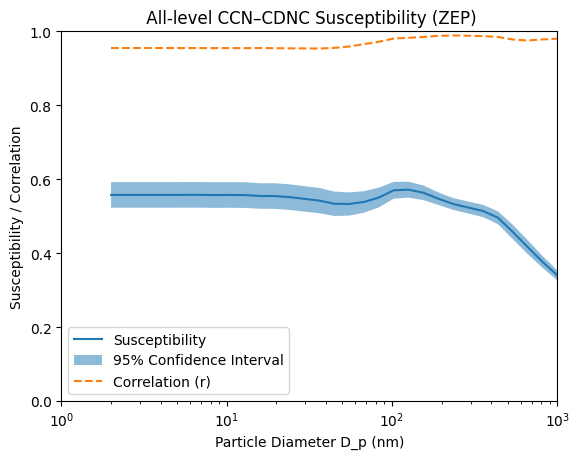

In [17]:
plt.plot(RADII*2, reg_ds['slope'].sel(station = 'ZEP'), label = 'Susceptibility')
plt.fill_between(RADII*2,
                 reg_ds['slope'].sel(station = 'ZEP')-1.98*reg_ds['std_err'].sel(station = 'ZEP'),
                 reg_ds['slope'].sel(station = 'ZEP')+1.98*reg_ds['std_err'].sel(station = 'ZEP'),
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(RADII*2, reg_ds['r_value'].sel(station = 'ZEP'), '--', label = 'Correlation (r)')
#plt.axvline(x=2*reg_ds['radius'].isel(radius=20).values, color='k', linestyle=':', label='Cutoff Cutoff Diameter')
plt.legend()
plt.title(" All-level CCN–CDNC Susceptibility (ZEP)")
plt.xlabel('Particle Diameter D_p (nm)')
plt.ylabel('Susceptibility / Correlation')
plt.ylim([-0, 1])
plt.xlim([1,1000])
plt.xscale('log')

### 4b · All stations grid

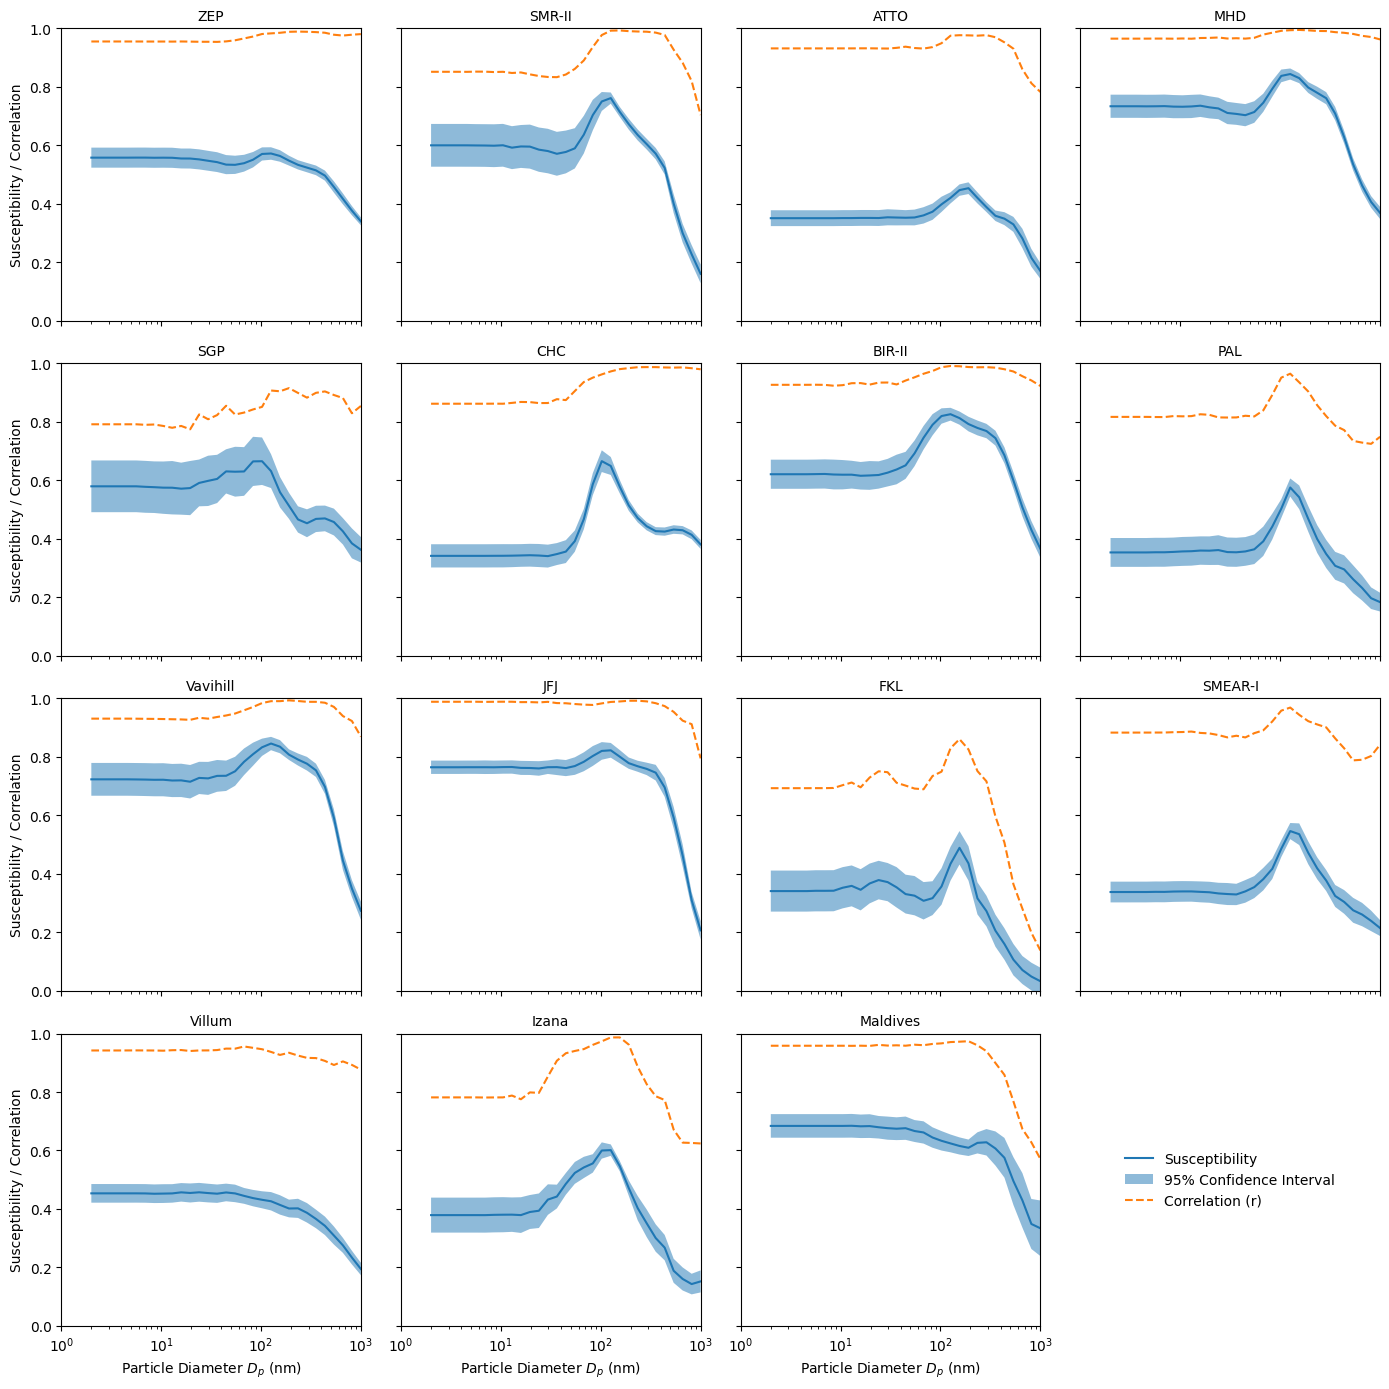

In [11]:
stations = reg_ds.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    slope = reg_ds['slope'].sel(station=station)
    std_err = reg_ds['std_err'].sel(station=station)
    r_val = reg_ds['r_value'].sel(station=station)

    ax.plot(RADII * 2, slope, label='Susceptibility')
    ax.fill_between(
        RADII * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.5,
        label='95% Confidence Interval'
    )
    ax.plot(
        RADII * 2,
        r_val,
        '--',
        label='Correlation (r)'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()



### 4c · Binned scatter diagnostic (SMR-II, one radius)

Shows the binned points the fit actually uses. Averaging is done in **log space** here too (geometric mean), so this plot is consistent with the Section-3 slopes. Error bars are the within-bin std of the logged values.

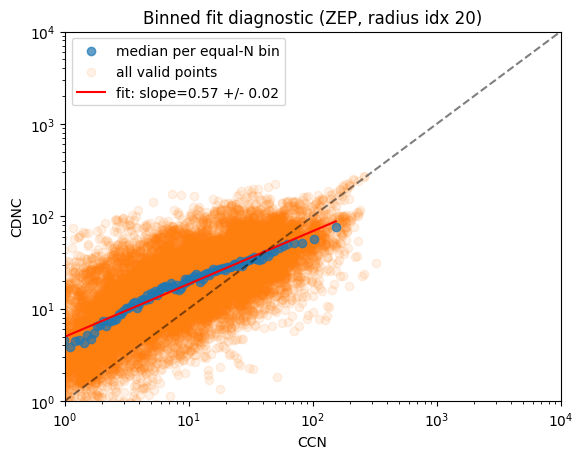

In [18]:
# Diagnostic: the binned points the fit actually uses, for one station/radius.
# Mirrors build_susceptibility_dataset_by_station: log-space, equal-number
# (quantile) bins, MEDIAN per bin — so this scatter matches the fitted slope.
st, ridx = 'ZEP', 20
n_bins = 100

ccn  = CCN_all['CCN'].sel(station=st).isel(radius=ridx).values.ravel()
cdnc = CCN_all['CDNC'].sel(station=st).values.ravel()
valid = np.isfinite(ccn) & np.isfinite(cdnc) & (ccn > 0) & (cdnc > 0)
lx, ly = np.log10(ccn[valid]), np.log10(cdnc[valid])

# equal-number bin edges in log space (same as the function)
bins = np.unique(np.quantile(lx, np.linspace(0, 1, n_bins + 1)))

lx_med, ly_med = [], []
for b in range(len(bins) - 1):
    if b == len(bins) - 2:
        m = (lx >= bins[b]) & (lx <= bins[b+1])
    else:
        m = (lx >= bins[b]) & (lx < bins[b+1])
    if m.sum() >= 2:
        lx_med.append(np.median(lx[m]))
        ly_med.append(np.median(ly[m]))
lx_med, ly_med = np.array(lx_med), np.array(ly_med)

# overlay the fitted line from reg_ds for this station/radius
slope = float(reg_ds['slope'].sel(station=st).isel(radius=ridx))
intercept = float(reg_ds['intercept'].sel(station=st).isel(radius=ridx))

plt.scatter(10**lx_med, 10**ly_med, alpha=0.7, label='median per equal-N bin')
xfit = np.array([10**lx_med.min(), 10**lx_med.max()])
plt.scatter(ccn[valid], cdnc[valid], alpha=0.1, label='all valid points', zorder=0)
plt.plot(xfit, 10**(intercept + slope*np.log10(xfit)), 'r-',
         label=f'fit: slope={slope:.2f} +/- {1.98*reg_ds["std_err"].sel(station=st).isel(radius=ridx).values:.2f}')
plt.xscale('log'); plt.yscale('log')
plt.xlim([1, 1e4]); plt.ylim([1, 1e4])
plt.plot([1, 1e4], [1, 1e4], 'k--', alpha=0.5)
plt.xlabel('CCN'); plt.ylabel('CDNC'); plt.legend()
plt.title(f'Binned fit diagnostic ({st}, radius idx {ridx})'); plt.show()

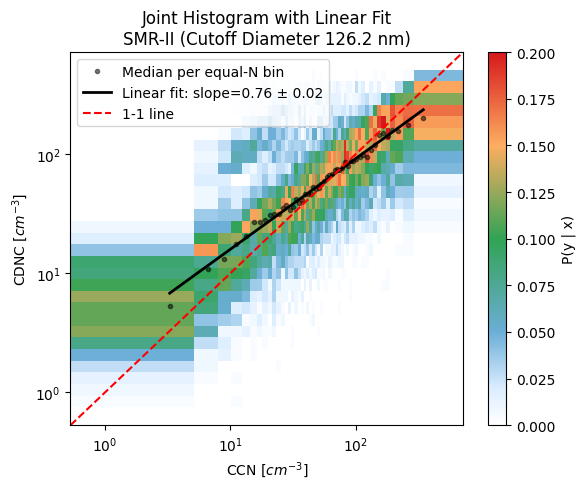

In [15]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator
cmap = LinearSegmentedColormap.from_list(
    "paper_style",
    [
        (0.0,  "#ffffff"),
        (0.1,  "#d9ecff"),
        (0.25, "#6baed6"),
        (0.5,  "#31a354"),
        (0.75, "#fdae61"),
        (1.0,  "#d7191c"),
    ],
)
st, ridx = 'SMR-II', 20
n_bins = 50

ccn  = CCN_all['CCN'].sel(station=st).isel(radius=ridx).values.ravel()
cdnc = CCN_all['CDNC'].sel(station=st).values.ravel()
valid = np.isfinite(ccn) & np.isfinite(cdnc) & (ccn > 0) & (cdnc > 0)
lx, ly = np.log10(ccn[valid]), np.log10(cdnc[valid])

# equal-number bin edges in log space (same as the function)
bins = np.unique(np.quantile(lx, np.linspace(0, 1, n_bins + 1)))

lx_med, ly_med = [], []
for b in range(len(bins) - 1):
    if b == len(bins) - 2:
        m = (lx >= bins[b]) & (lx <= bins[b+1])
    else:
        m = (lx >= bins[b]) & (lx < bins[b+1])
    if m.sum() >= 2:
        lx_med.append(np.median(lx[m]))
        ly_med.append(np.median(ly[m]))
lx_med, ly_med = np.array(lx_med), np.array(ly_med)

# fitted line from reg_ds for this station/radius
slope = float(reg_ds['slope'].sel(station=st).isel(radius=ridx))
intercept = float(reg_ds['intercept'].sel(station=st).isel(radius=ridx))
std_err = float(reg_ds['std_err'].sel(station=st).isel(radius=ridx))

# --- joint histogram P(y|x): equal-frequency x-bins, linear y-bins ---
g_min = min(lx.min(), ly.min())
g_max = max(lx.max(), ly.max())

xbins = bins  # equal-number edges in log-space, reused
ybins = np.linspace(ly.min(), ly.max(), 30)
H, xedges, yedges = np.histogram2d(lx, ly, bins=[xbins, ybins])
H_norm = np.nan_to_num(H / H.sum(axis=1, keepdims=True))

fig, ax = plt.subplots(figsize=(6, 5))
pcm = ax.pcolormesh(xedges, yedges, H_norm.T, cmap=cmap, shading="auto", vmin=0, vmax=0.2)

ax.plot(lx_med, ly_med, "k.", alpha=0.5, label="Median per equal-N bin")

xfit = np.array([lx_med.min(), lx_med.max()])
ax.plot(xfit, intercept + slope * xfit, "k-", linewidth=2,
        label=f"Linear fit: slope={slope:.2f} ± {1.98*std_err:.2f}")

ax.plot([g_min, g_max], [g_min, g_max], ls="--", c="red", label="1-1 line")
ax.set_xlim(g_min, g_max)
ax.set_ylim(g_min, g_max)

# ticks at integer log10 values, labelled as powers of ten
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
pow_fmt = FuncFormatter(lambda v, _: rf"$10^{{{int(v)}}}$")
ax.xaxis.set_major_formatter(pow_fmt)
ax.yaxis.set_major_formatter(pow_fmt)

ax.set_xlabel("CCN [$cm^{-3}$]")
ax.set_ylabel("CDNC [$cm^{-3}$]")
ax.set_title(f"Joint Histogram with Linear Fit\n{st} (Cutoff Diameter {2*reg_ds['radius'].isel(radius=ridx).values:.1f} nm)")
ax.legend()
fig.colorbar(pcm, ax=ax, label="P(y | x)")

plt.tight_layout()
plt.show()

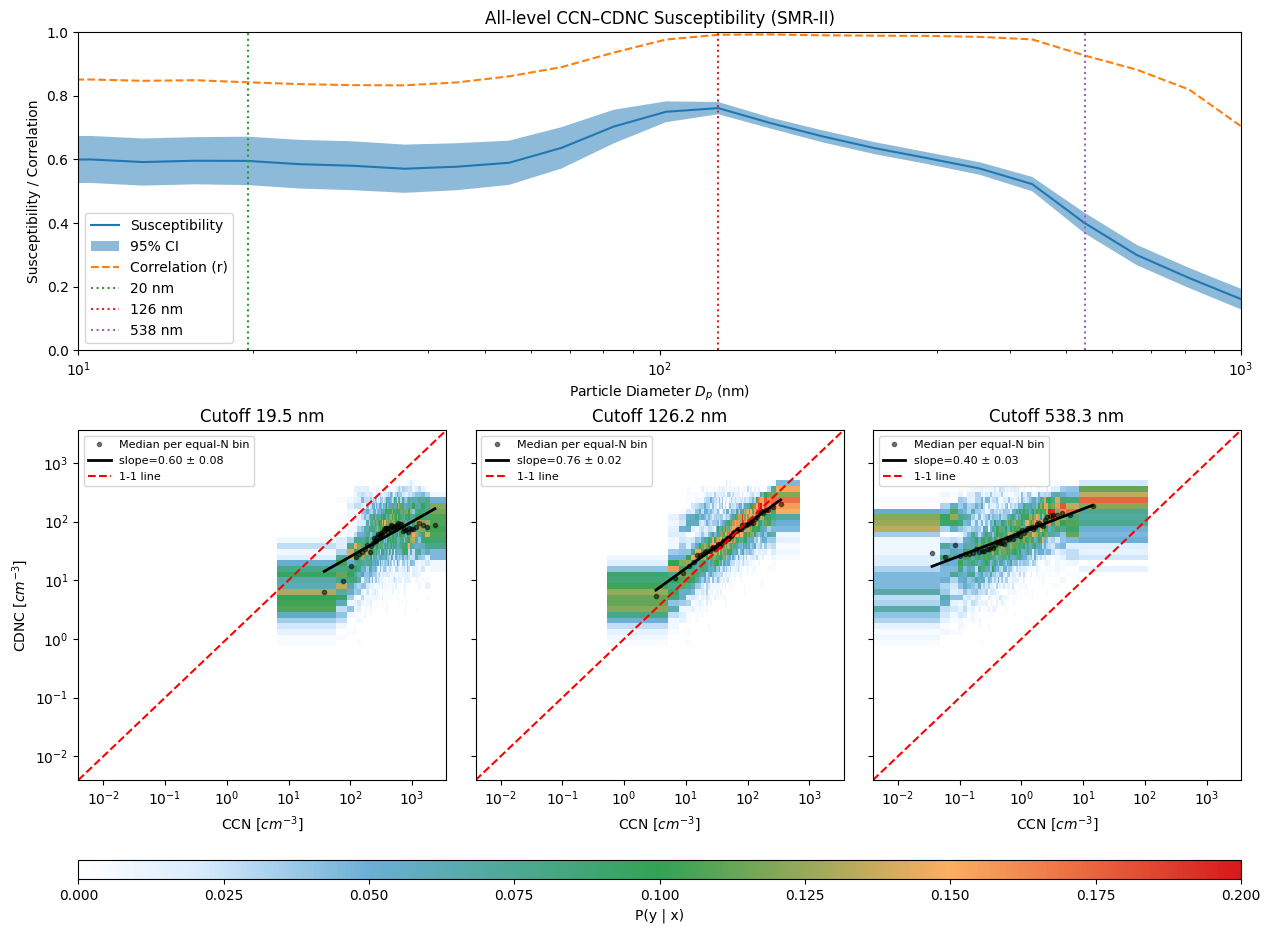

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator

cmap = LinearSegmentedColormap.from_list(
    "paper_style",
    [
        (0.0,  "#ffffff"),
        (0.1,  "#d9ecff"),
        (0.25, "#6baed6"),
        (0.5,  "#31a354"),
        (0.75, "#fdae61"),
        (1.0,  "#d7191c"),
    ],
)

st = 'SMR-II'
n_bins = 50
pow_fmt = FuncFormatter(lambda v, _: rf"$10^{{{int(v)}}}$")

# --- pick cutoff radius indices from the susceptibility curve ---
slope_curve = reg_ds['slope'].sel(station=st).values
diam = 2 * reg_ds['radius'].values  # nm

imax = int(np.nanargmax(slope_curve))          # peak susceptibility
i20 = int(np.nanargmin(np.abs(diam - 20)))     # nearest to 20 nm
i500 = int(np.nanargmin(np.abs(diam - 500)))   # nearest to 500 nm
panel_idxs = [i20, imax, i500]

# --- precompute panel data + global axis range for shared axes ---
def panel_data(ridx):
    ccn  = CCN_all['CCN'].sel(station=st).isel(radius=ridx).values.ravel()
    cdnc = CCN_all['CDNC'].sel(station=st).values.ravel()
    valid = np.isfinite(ccn) & np.isfinite(cdnc) & (ccn > 0) & (cdnc > 0)
    lx, ly = np.log10(ccn[valid]), np.log10(cdnc[valid])

    bins = np.unique(np.quantile(lx, np.linspace(0, 1, n_bins + 1)))
    lx_med, ly_med = [], []
    for b in range(len(bins) - 1):
        if b == len(bins) - 2:
            m = (lx >= bins[b]) & (lx <= bins[b+1])
        else:
            m = (lx >= bins[b]) & (lx < bins[b+1])
        if m.sum() >= 2:
            lx_med.append(np.median(lx[m]))
            ly_med.append(np.median(ly[m]))
    lx_med, ly_med = np.array(lx_med), np.array(ly_med)

    ybins = np.linspace(ly.min(), ly.max(), 30)
    H, xedges, yedges = np.histogram2d(lx, ly, bins=[bins, ybins])
    H_norm = np.nan_to_num(H / H.sum(axis=1, keepdims=True))

    return dict(
        lx=lx, ly=ly, lx_med=lx_med, ly_med=ly_med,
        xedges=xedges, yedges=yedges, H_norm=H_norm,
        slope=float(reg_ds['slope'].sel(station=st).isel(radius=ridx)),
        intercept=float(reg_ds['intercept'].sel(station=st).isel(radius=ridx)),
        std_err=float(reg_ds['std_err'].sel(station=st).isel(radius=ridx)),
    )

pdata = [panel_data(r) for r in panel_idxs]

# global range across all panels so the 1-1 line stays diagonal everywhere
g_min = min(min(d['lx'].min(), d['ly'].min()) for d in pdata)
g_max = max(max(d['lx'].max(), d['ly'].max()) for d in pdata)

# --- layout ---
fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1.1, 0.06], hspace=0.35, wspace=0.08)

# top: susceptibility curve spanning all columns
ax_curve = fig.add_subplot(gs[0, :])
sl = reg_ds['slope'].sel(station=st)
se = reg_ds['std_err'].sel(station=st)
ax_curve.plot(diam, sl, label='Susceptibility')
ax_curve.fill_between(diam, sl - 1.98*se, sl + 1.98*se, alpha=0.5, label='95% CI')
ax_curve.plot(diam, reg_ds['r_value'].sel(station=st), '--', label='Correlation (r)')
for ridx, c in zip(panel_idxs, ['tab:green', 'tab:red', 'tab:purple']):
    ax_curve.axvline(diam[ridx], color=c, linestyle=':', label=f'{diam[ridx]:.0f} nm')
ax_curve.set_title(f"All-level CCN–CDNC Susceptibility ({st})")
ax_curve.set_xlabel('Particle Diameter $D_p$ (nm)')
ax_curve.set_ylabel('Susceptibility / Correlation')
ax_curve.set_ylim([-0,1])
ax_curve.set_xlim([10, 1000])
ax_curve.set_xscale('log')
ax_curve.legend()

# bottom: three shared-axis joint-histogram panels
panel_axes = []
pcm = None
for col, (ridx, d) in enumerate(zip(panel_idxs, pdata)):
    sharex = panel_axes[0] if panel_axes else None
    ax = fig.add_subplot(gs[1, col], sharex=sharex, sharey=sharex)
    panel_axes.append(ax)

    pcm = ax.pcolormesh(d['xedges'], d['yedges'], d['H_norm'].T,
                        cmap=cmap, shading="auto", vmin=0, vmax=0.2)
    ax.plot(d['lx_med'], d['ly_med'], "k.", alpha=0.5, label="Median per equal-N bin")
    xfit = np.array([d['lx_med'].min(), d['lx_med'].max()])
    ax.plot(xfit, d['intercept'] + d['slope'] * xfit, "k-", linewidth=2,
            label=f"slope={d['slope']:.2f} ± {1.98*d['std_err']:.2f}")
    ax.plot([g_min, g_max], [g_min, g_max], ls="--", c="red", label="1-1 line")

    ax.set_xlim(g_min, g_max)
    ax.set_ylim(g_min, g_max)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(pow_fmt)
    ax.yaxis.set_major_formatter(pow_fmt)
    ax.set_xlabel("CCN [$cm^{-3}$]")
    ax.set_title(f"Cutoff {diam[ridx]:.1f} nm")
    ax.legend(fontsize=8, loc='upper left')

    if col == 0:
        ax.set_ylabel("CDNC [$cm^{-3}$]")
    else:
        ax.tick_params(labelleft=False)  # hide y tick labels on shared panels

# horizontal colorbar under the three panels
cax = fig.add_subplot(gs[2, :])
fig.colorbar(pcm, cax=cax, orientation='horizontal', label="P(y | x)")

plt.show()

## 5 · Save results (optional)

Persist `reg_ds` so downstream notebooks (e.g. clustering) can load it without re-running the expensive binning. Set `SAVE_PATH` in Section 1 to enable.

In [ ]:
import gc
ds.close()                          # release the locked input file handle
gc.collect()
reg_ds.to_netcdf(SAVE_PATH, engine='netcdf4', mode='w')
print('saved ->', SAVE_PATH)

saved -> /share/pech2273/NorESM_Susceptibility_All_level.nc
